In [2]:
import os

# Replace 'your_username' and 'your_key' with your actual Kaggle credentials
os.environ['KAGGLE_USERNAME'] = "amanquantum"
os.environ['KAGGLE_KEY'] = "KGAT_ecacedefbbe240bb18d2c1c3bdbb9ce6"

import kagglehub
path = kagglehub.dataset_download("orvile/wesad-wearable-stress-affect-detection-dataset")

Using Colab cache for faster access to the 'wesad-wearable-stress-affect-detection-dataset' dataset.


In [3]:
import os
import pickle
import numpy as np
import pandas as pd

def load_subject(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

wesad_path = "/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD"

subjects = sorted([s for s in os.listdir(wesad_path) if s.startswith("S")])

print("Subjects:", subjects)
print("Total Subjects:", len(subjects))

Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Total Subjects: 15


In [9]:
# PREPROCESSING + DATA BUILD

import os
import pickle
import numpy as np
import pandas as pd

def load_subject(file_path):
    with open(file_path, 'rb') as f:
        return pickle.load(f, encoding='latin1')

wesad_path = "/kaggle/input/wesad-wearable-stress-affect-detection-dataset/WESAD"

subjects = sorted([s for s in os.listdir(wesad_path) if s.startswith("S")])
print("Subjects:", subjects)

all_data = []

for subject in subjects:
    data = load_subject(os.path.join(wesad_path, subject, f"{subject}.pkl"))
    wrist = data["signal"]["wrist"]

    # extracting signals
    EDA = wrist["EDA"].flatten()
    TEMP = wrist["TEMP"].flatten()
    BVP = wrist["BVP"].flatten()
    labels = data["label"]

    # downsampling (BVP is high freq, labels also need alignment)
    BVP = BVP[::16]
    labels = labels[::175]

    # align all signals to same length
    min_len = min(len(EDA), len(TEMP), len(BVP), len(labels))

    df_sub = pd.DataFrame({
        "EDA": EDA[:min_len],
        "TEMP": TEMP[:min_len],
        "BVP": BVP[:min_len],
        "Label": labels[:min_len],
        "Subject": subject
    })

    all_data.append(df_sub)

# combine all subjects
df = pd.concat(all_data, ignore_index=True)

# keep only 3 classes: baseline, stress, amusement
df = df[df["Label"].isin([1,2,3])]

# remap labels to integer 0,1,2
df["Label"] = df["Label"].map({1:0, 2:1, 3:2}).astype(int)

print("Final Data Shape:", df.shape)

Subjects: ['S10', 'S11', 'S13', 'S14', 'S15', 'S16', 'S17', 'S2', 'S3', 'S4', 'S5', 'S6', 'S7', 'S8', 'S9']
Final Data Shape: (132608, 5)


In [10]:
import pandas as pd

print(df.head(5))

          EDA   TEMP     BVP  Label Subject
372  0.373519  33.25  -80.81      0     S10
373  0.374798  33.23  134.82      0     S10
374  0.373519  33.23   17.70      0     S10
375  0.376077  33.23  -12.60      0     S10
376  0.372240  33.23   16.44      0     S10


In [ ]:
# WINDOWING

WINDOW = 180
STEP = 60

X, y, subj_ids = [], [], []

# going subject by subject, important for LOSO later maybe :X
for subject in df["Subject"].unique():

    sub_df = df[df["Subject"] == subject]
    data = sub_df[["EDA","TEMP","BVP"]].values
    labels = sub_df["Label"].values

    # sliding window
    for i in range(0, len(data)-WINDOW, STEP):
        window = data[i:i+WINDOW]

        # assign label based on majority in window
        label = np.bincount(labels[i:i+WINDOW]).argmax()

        X.append(window)
        y.append(label)
        subj_ids.append(subject)

X = np.array(X)
y = np.array(y)
subj_ids = np.array(subj_ids)

print("Windowed Data Shape:", X.shape)

Windowed Data Shape: (2172, 180, 3)


In [ ]:
# PRECOMPUTE SPECTROGRAMS

from scipy.signal import stft

def compute_spectrogram(x):
    specs = []
    for i in range(3):  # EDA, TEMP, BVP
        _, _, Z = stft(x[:, i], nperseg=128, noverlap=64)
        specs.append(np.log1p(np.abs(Z)))  # log scaling stability
    return np.stack(specs, axis=0)

print("Precomputing spectrograms...")

X_spec = np.array([compute_spectrogram(x) for x in X])

print("Spectrogram shape:", X_spec.shape)

Precomputing spectrograms...
Spectrogram shape: (2172, 3, 65, 4)


In [ ]:
# CNN MODEL

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

class SpecDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return (
            torch.tensor(self.X[i], dtype=torch.float32),
            torch.tensor(self.y[i], dtype=torch.long)
        )


class SpectrogramCNN(nn.Module):
    def __init__(self, dropout=0.4):
        super().__init__()

        # feature extractor
        self.features = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),
            nn.Dropout2d(0.3),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1,1))
        )

        # classifier
        self.classifier = nn.Sequential(
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(128, 3)
        )

    def forward(self, x):
        x = self.features(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# BASELINE

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

EPOCHS = 100
BATCH_SIZE = 32
LR = 3e-4

unique_subjects = np.unique(subj_ids)

all_acc, all_f1 = [], []

for test_sub in unique_subjects:

    print(f"\n===== LOSO: Testing on {test_sub} ===telek==")

    train_idx = subj_ids != test_sub
    test_idx  = subj_ids == test_sub

    X_train, y_train = X_spec[train_idx], y[train_idx]
    X_test,  y_test  = X_spec[test_idx],  y[test_idx]


    # Normalization
    mean = X_train.mean(axis=(0,2,3), keepdims=True)
    std  = X_train.std(axis=(0,2,3), keepdims=True) + 1e-6

    X_train = (X_train - mean) / std
    X_test  = (X_test  - mean) / std

    # Class weights
    cls = np.array([0,1,2])
    class_weights = compute_class_weight(
        class_weight='balanced',
        classes=cls,
        y=y_train
    )
    class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)

    train_loader = DataLoader(
        SpecDataset(X_train, y_train),
        batch_size=BATCH_SIZE,
        shuffle=True
    )

    test_loader = DataLoader(
        SpecDataset(X_test, y_test),
        batch_size=BATCH_SIZE,
        shuffle=False
    )

    model = SpectrogramCNN(dropout=0.4).to(device) # Dropout reduced to 0.4


    # Loss + Optimization
    criterion = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
        optimizer,
        T_max=EPOCHS
    )

    # Training
    for epoch in range(EPOCHS):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            outputs = model(xb)
            loss = criterion(outputs, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        scheduler.step()

        print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {total_loss:.4f}")

    # Save model (needed for M7)
    torch.save(model.state_dict(), f"model_{test_sub}.pth")

    # Evaluation
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(pred.tolist())
            targets.extend(yb.numpy().tolist())

    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, average='macro', zero_division=0)
    rec  = recall_score(targets, preds, average='macro', zero_division=0)
    f1   = f1_score(targets, preds, average='macro', zero_division=0)

    print(f"Subject {test_sub}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    all_acc.append(acc)
    all_f1.append(f1)

print("\n===== FINAL M6 RESULTS ====")
print("Mean Accuracy:", float(np.mean(all_acc)))
print("Mean F1:", float(np.mean(all_f1)))


===== LOSO: Testing on S10 ===telek==
Epoch 1/100 | Loss: 68.5146
Epoch 2/100 | Loss: 66.9997
Epoch 3/100 | Loss: 65.4117
Epoch 4/100 | Loss: 64.8123
Epoch 5/100 | Loss: 64.1170
Epoch 6/100 | Loss: 63.7676
Epoch 7/100 | Loss: 62.9463
Epoch 8/100 | Loss: 62.7583
Epoch 9/100 | Loss: 62.3859
Epoch 10/100 | Loss: 61.5742
Epoch 11/100 | Loss: 61.7431
Epoch 12/100 | Loss: 61.3440
Epoch 13/100 | Loss: 60.1850
Epoch 14/100 | Loss: 60.3716
Epoch 15/100 | Loss: 59.6482
Epoch 16/100 | Loss: 59.8363
Epoch 17/100 | Loss: 59.7156
Epoch 18/100 | Loss: 59.0094
Epoch 19/100 | Loss: 57.9378
Epoch 20/100 | Loss: 58.2595
Epoch 21/100 | Loss: 57.0675
Epoch 22/100 | Loss: 56.9075
Epoch 23/100 | Loss: 57.3446
Epoch 24/100 | Loss: 58.3916
Epoch 25/100 | Loss: 56.0384
Epoch 26/100 | Loss: 55.4583
Epoch 27/100 | Loss: 55.2286
Epoch 28/100 | Loss: 55.2011
Epoch 29/100 | Loss: 54.9160
Epoch 30/100 | Loss: 55.1466
Epoch 31/100 | Loss: 54.5017
Epoch 32/100 | Loss: 53.8232
Epoch 33/100 | Loss: 53.4140
Epoch 34/100 

In [ ]:
# PERSONALIZATION

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import copy

PERSONAL_EPOCHS = 100
LR_FINE = 1e-4

all_personal_acc = []
all_personal_f1 = []

unique_subjects = np.unique(subj_ids)

for subject in unique_subjects:

    print(f"\n===== PERSONALIZATION: {subject} ====")

    # Load subject data
    idx = subj_ids == subject
    X_sub = X_spec[idx]
    y_sub = y[idx]

    # Normalize (same as training)
    mean = X_sub.mean(axis=(0,2,3), keepdims=True)
    std  = X_sub.std(axis=(0,2,3), keepdims=True) + 1e-6
    X_sub = (X_sub - mean) / std

    # Split 20% fine tune, 80% test
    X_train, X_test, y_train, y_test = train_test_split(
        X_sub, y_sub, test_size=0.8, stratify=y_sub, random_state=42
    )

    train_loader = DataLoader(SpecDataset(X_train, y_train), batch_size=16, shuffle=True)
    test_loader  = DataLoader(SpecDataset(X_test, y_test), batch_size=16, shuffle=False)

    # Load global model (from M6)
    model = SpectrogramCNN(dropout=0.4).to(device)
    model.load_state_dict(torch.load(f"model_{subject}.pth"))


    # Freeze CNN backbone
    for param in model.features.parameters(): # Corrected: model.net -> model.features
        param.requires_grad = False

    # Only train classifier
    optimizer = torch.optim.AdamW(model.classifier.parameters(), lr=LR_FINE) # Corrected: model.fc to model.classifier
    criterion = nn.CrossEntropyLoss()

    # Train classifier only
    for epoch in range(PERSONAL_EPOCHS // 2):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"[Frozen] Epoch {epoch+1} | Loss: {total_loss:.4f}")

    # Unfreeze last conv block
    for param in model.features[-3:].parameters():  # Corrected: model.net -> model.features
        param.requires_grad = True

    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_FINE/2)

    #Fine tuning
    for epoch in range(PERSONAL_EPOCHS // 2):
        model.train()
        total_loss = 0

        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)

            optimizer.zero_grad()
            out = model(xb)
            loss = criterion(out, yb)

            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

            total_loss += loss.item()

        print(f"[Unfrozen] Epoch {epoch+1} | Loss: {total_loss:.4f}")


    # Evaluation
    model.eval()
    preds, targets = [], []

    with torch.no_grad():
        for xb, yb in test_loader:
            xb = xb.to(device)
            logits = model(xb)
            pred = torch.argmax(logits, dim=1).cpu().numpy()

            preds.extend(pred.tolist())
            targets.extend(yb.numpy().tolist())

    acc = accuracy_score(targets, preds)
    prec = precision_score(targets, preds, average='macro', zero_division=0)
    rec  = recall_score(targets, preds, average='macro', zero_division=0)
    f1   = f1_score(targets, preds, average='macro', zero_division=0)

    print(f"Personalized {subject}: Acc={acc:.4f}, Prec={prec:.4f}, Rec={rec:.4f}, F1={f1:.4f}")

    all_personal_acc.append(acc)
    all_personal_f1.append(f1)


# Final Results
print("\n===== FINAL PERSONALIZED RESULTS ====")
print("Mean Accuracy:", float(np.mean(all_personal_acc)))
print("Mean F1:", float(np.mean(all_personal_f1)))



===== PERSONALIZATION: S10 ====
[Frozen] Epoch 1 | Loss: 2.4807
[Frozen] Epoch 2 | Loss: 2.1750
[Frozen] Epoch 3 | Loss: 2.1848
[Frozen] Epoch 4 | Loss: 2.5926
[Frozen] Epoch 5 | Loss: 2.2818
[Frozen] Epoch 6 | Loss: 2.0692
[Frozen] Epoch 7 | Loss: 2.4148
[Frozen] Epoch 8 | Loss: 1.9871
[Frozen] Epoch 9 | Loss: 2.2058
[Frozen] Epoch 10 | Loss: 2.2159
[Frozen] Epoch 11 | Loss: 1.9785
[Frozen] Epoch 12 | Loss: 1.8202
[Frozen] Epoch 13 | Loss: 1.6196
[Frozen] Epoch 14 | Loss: 2.0597
[Frozen] Epoch 15 | Loss: 2.0010
[Frozen] Epoch 16 | Loss: 1.7410
[Frozen] Epoch 17 | Loss: 1.9012
[Frozen] Epoch 18 | Loss: 1.7017
[Frozen] Epoch 19 | Loss: 1.8354
[Frozen] Epoch 20 | Loss: 1.7548
[Frozen] Epoch 21 | Loss: 1.8516
[Frozen] Epoch 22 | Loss: 1.8229
[Frozen] Epoch 23 | Loss: 1.6743
[Frozen] Epoch 24 | Loss: 1.6515
[Frozen] Epoch 25 | Loss: 1.6346
[Frozen] Epoch 26 | Loss: 1.6763
[Frozen] Epoch 27 | Loss: 1.8925
[Frozen] Epoch 28 | Loss: 1.7324
[Frozen] Epoch 29 | Loss: 1.6227
[Frozen] Epoch 30 |

<class 'numpy.ndarray'> (2172, 180, 3)
<class 'numpy.ndarray'> (2172, 3, 65, 4)


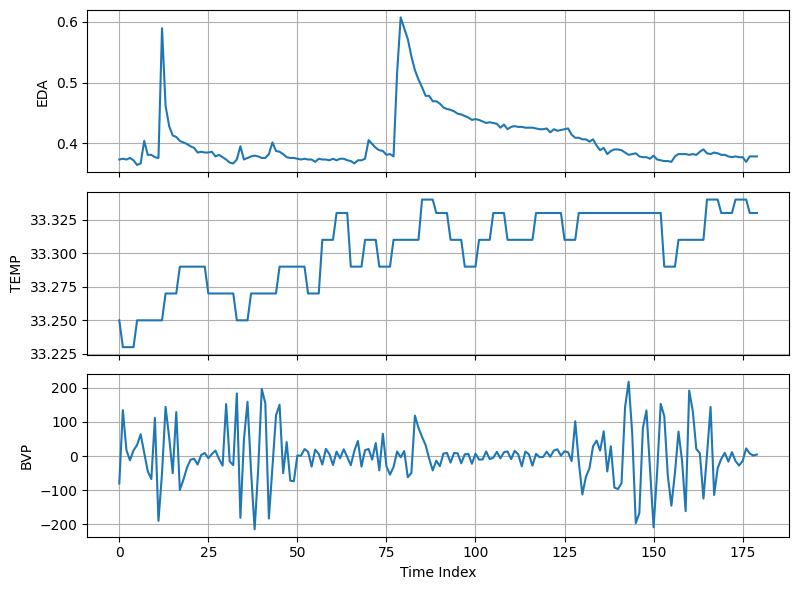

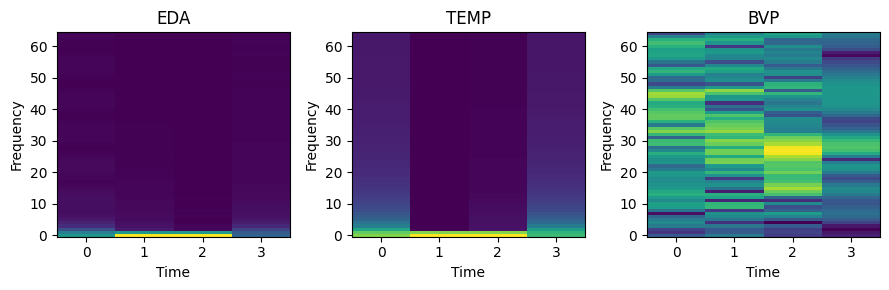

In [ ]:
import matplotlib.pyplot as plt

# check if variables exist
print(type(X), X.shape)
print(type(X_spec), X_spec.shape)

idx = 0  # choose sample

# Raw signals
sample = X[idx]

fig, axes = plt.subplots(3, 1, figsize=(8, 6), sharex=True)
labels = ["EDA", "TEMP", "BVP"]

for i in range(3):
    axes[i].plot(sample[:, i])
    axes[i].set_ylabel(labels[i])
    axes[i].grid(True)

axes[-1].set_xlabel("Time Index")
plt.tight_layout()
plt.savefig("signals.png", dpi=300)
plt.show()


# Spectrogram
spec = X_spec[idx]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
titles = ["EDA", "TEMP", "BVP"]

for i in range(3):
    axes[i].imshow(spec[i], aspect='auto', origin='lower')
    axes[i].set_title(titles[i])
    axes[i].set_xlabel("Time")
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.savefig("spectrograms.png", dpi=300)
plt.show()